Gotta make some tuning curves

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

#JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# 
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

#
trials = [[1,3],[1,5,7],[1],[2],
    [2,3],[1,3],
    [1,3,4],[1,2,3],[1,2],[1,3],
    [4,5],[1,3],[3,4],[4,5],[2,5],
    [1,3],[1,2],[1,3],[5,7,8],[3,5],
]

In [2]:
%load_ext autoreload
from behave_analysis.process.process import Process
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, compute_dist_shelt, compute_escape_trajectory, compress_vars, discretize_x_axis, firing_by_bin

import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap, utils
from scipy.stats import zscore
%matplotlib inline

In [44]:
esc_var, escape_matrix, start = extract_escape_time(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, 'y_pos')

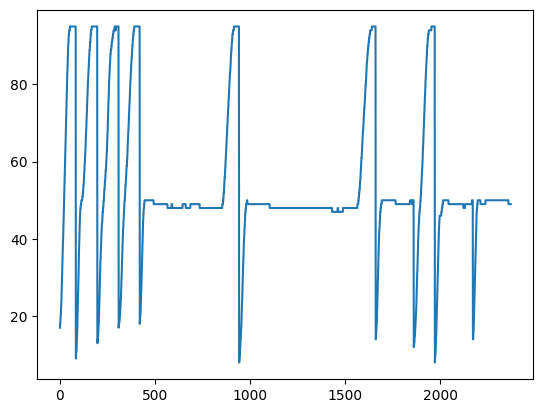

In [45]:
plt.plot(esc_var)

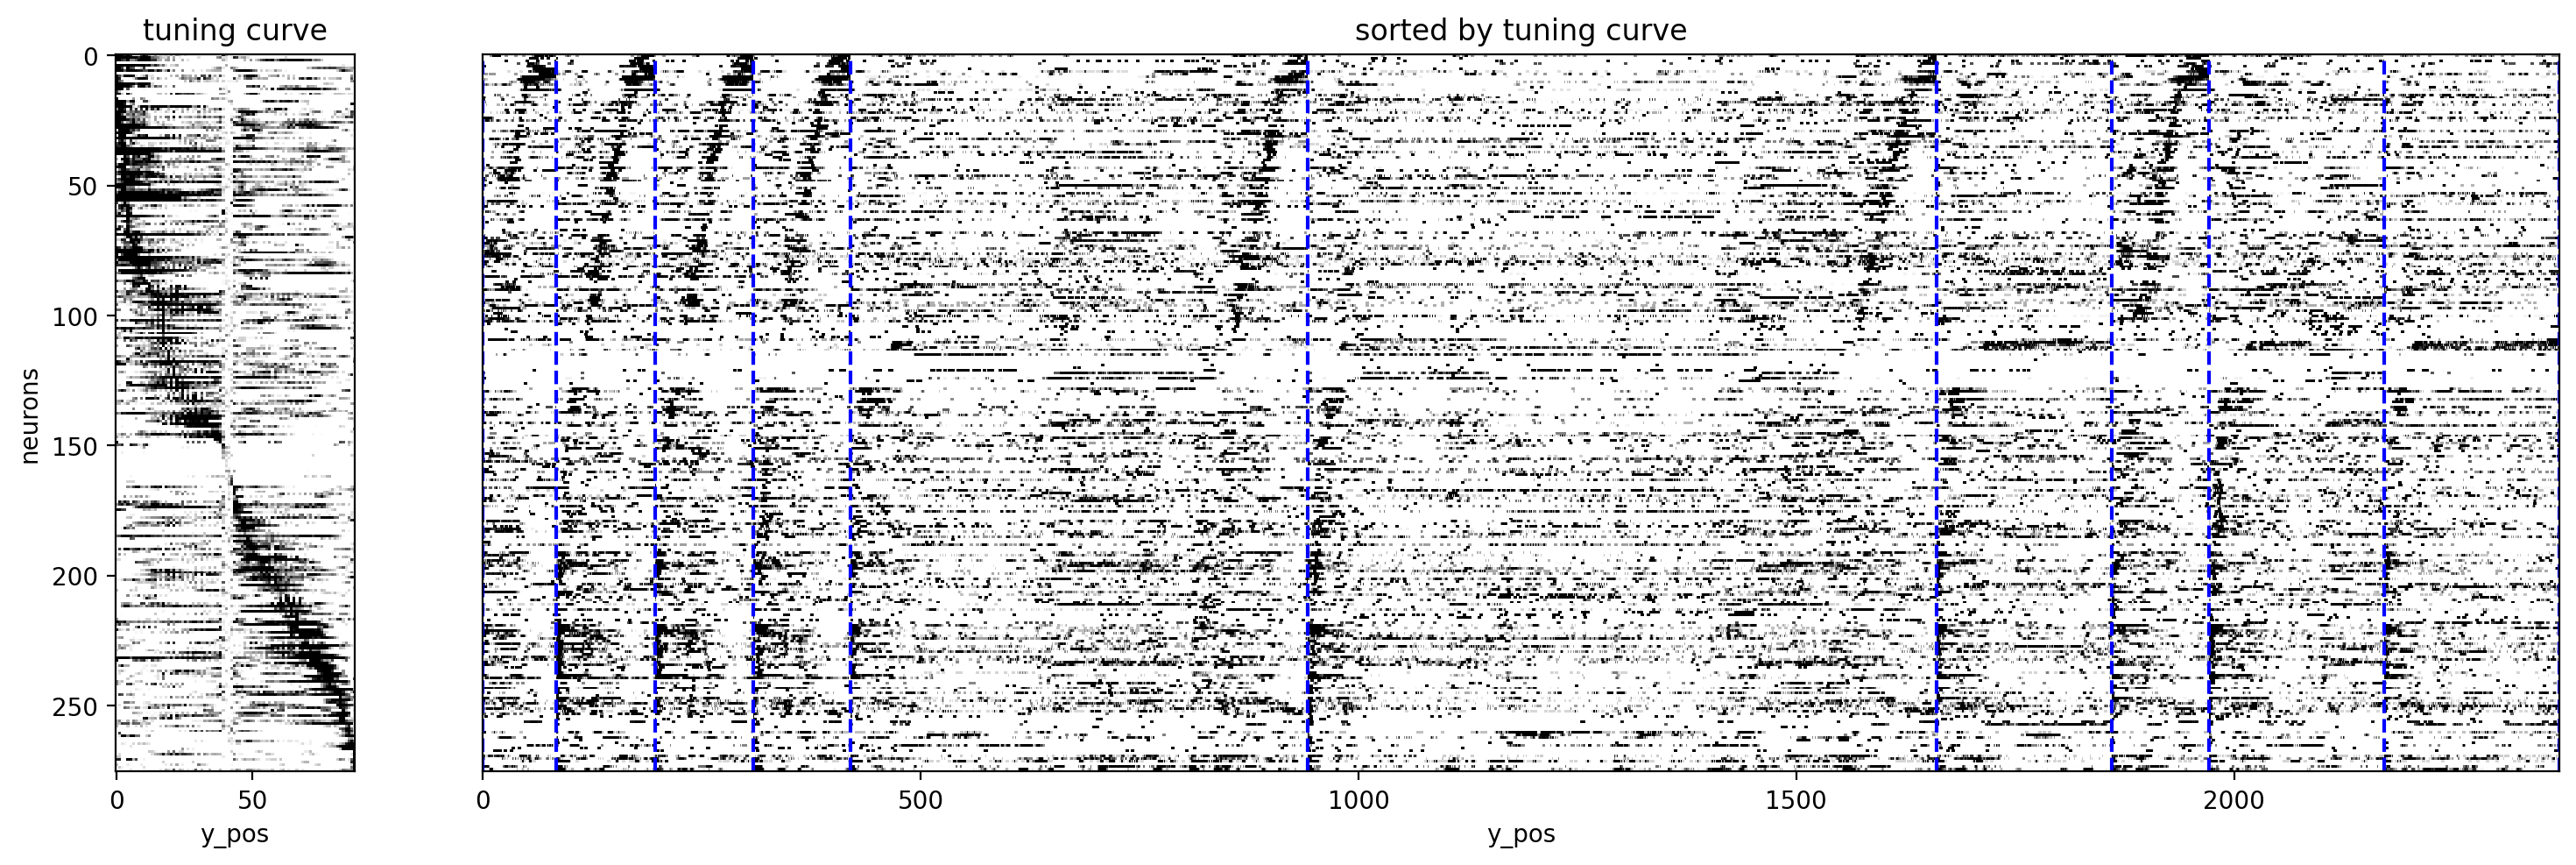

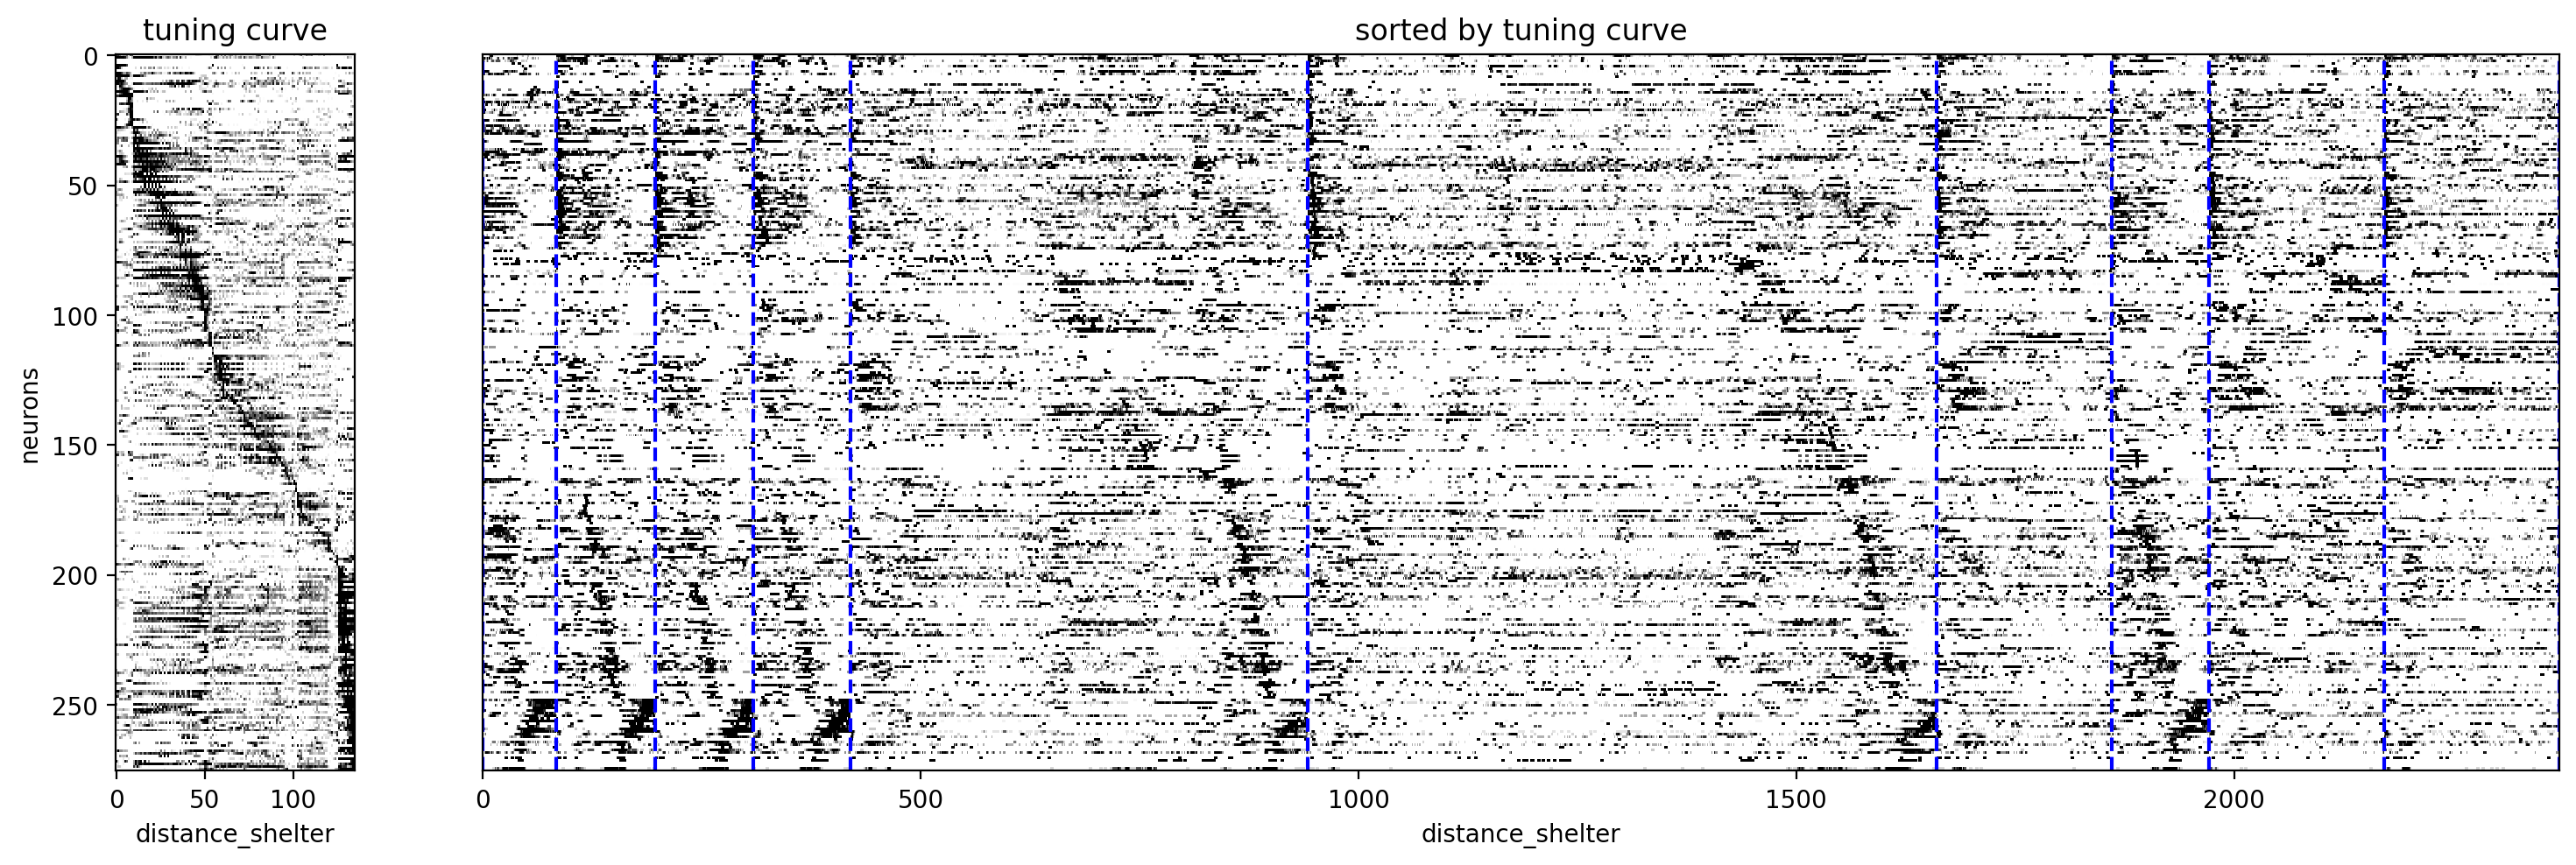

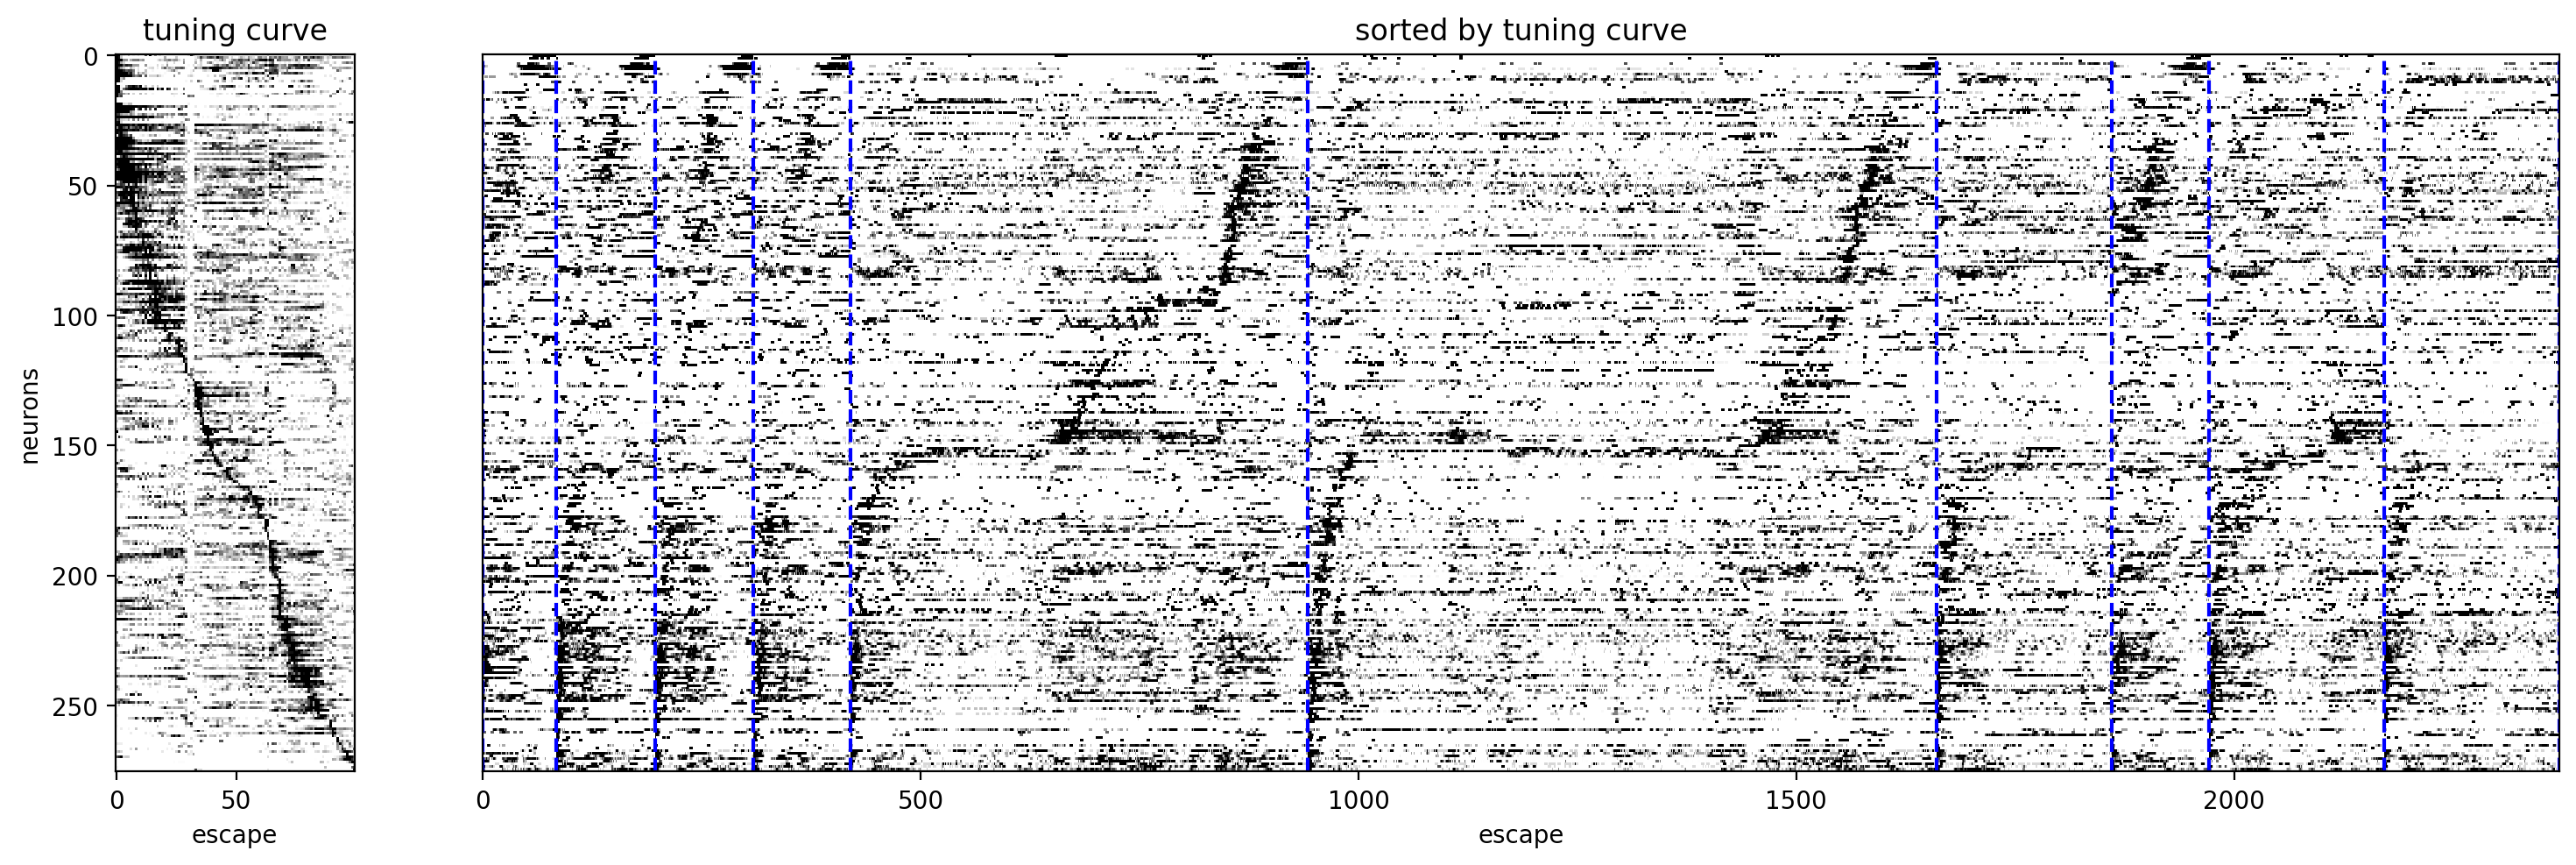

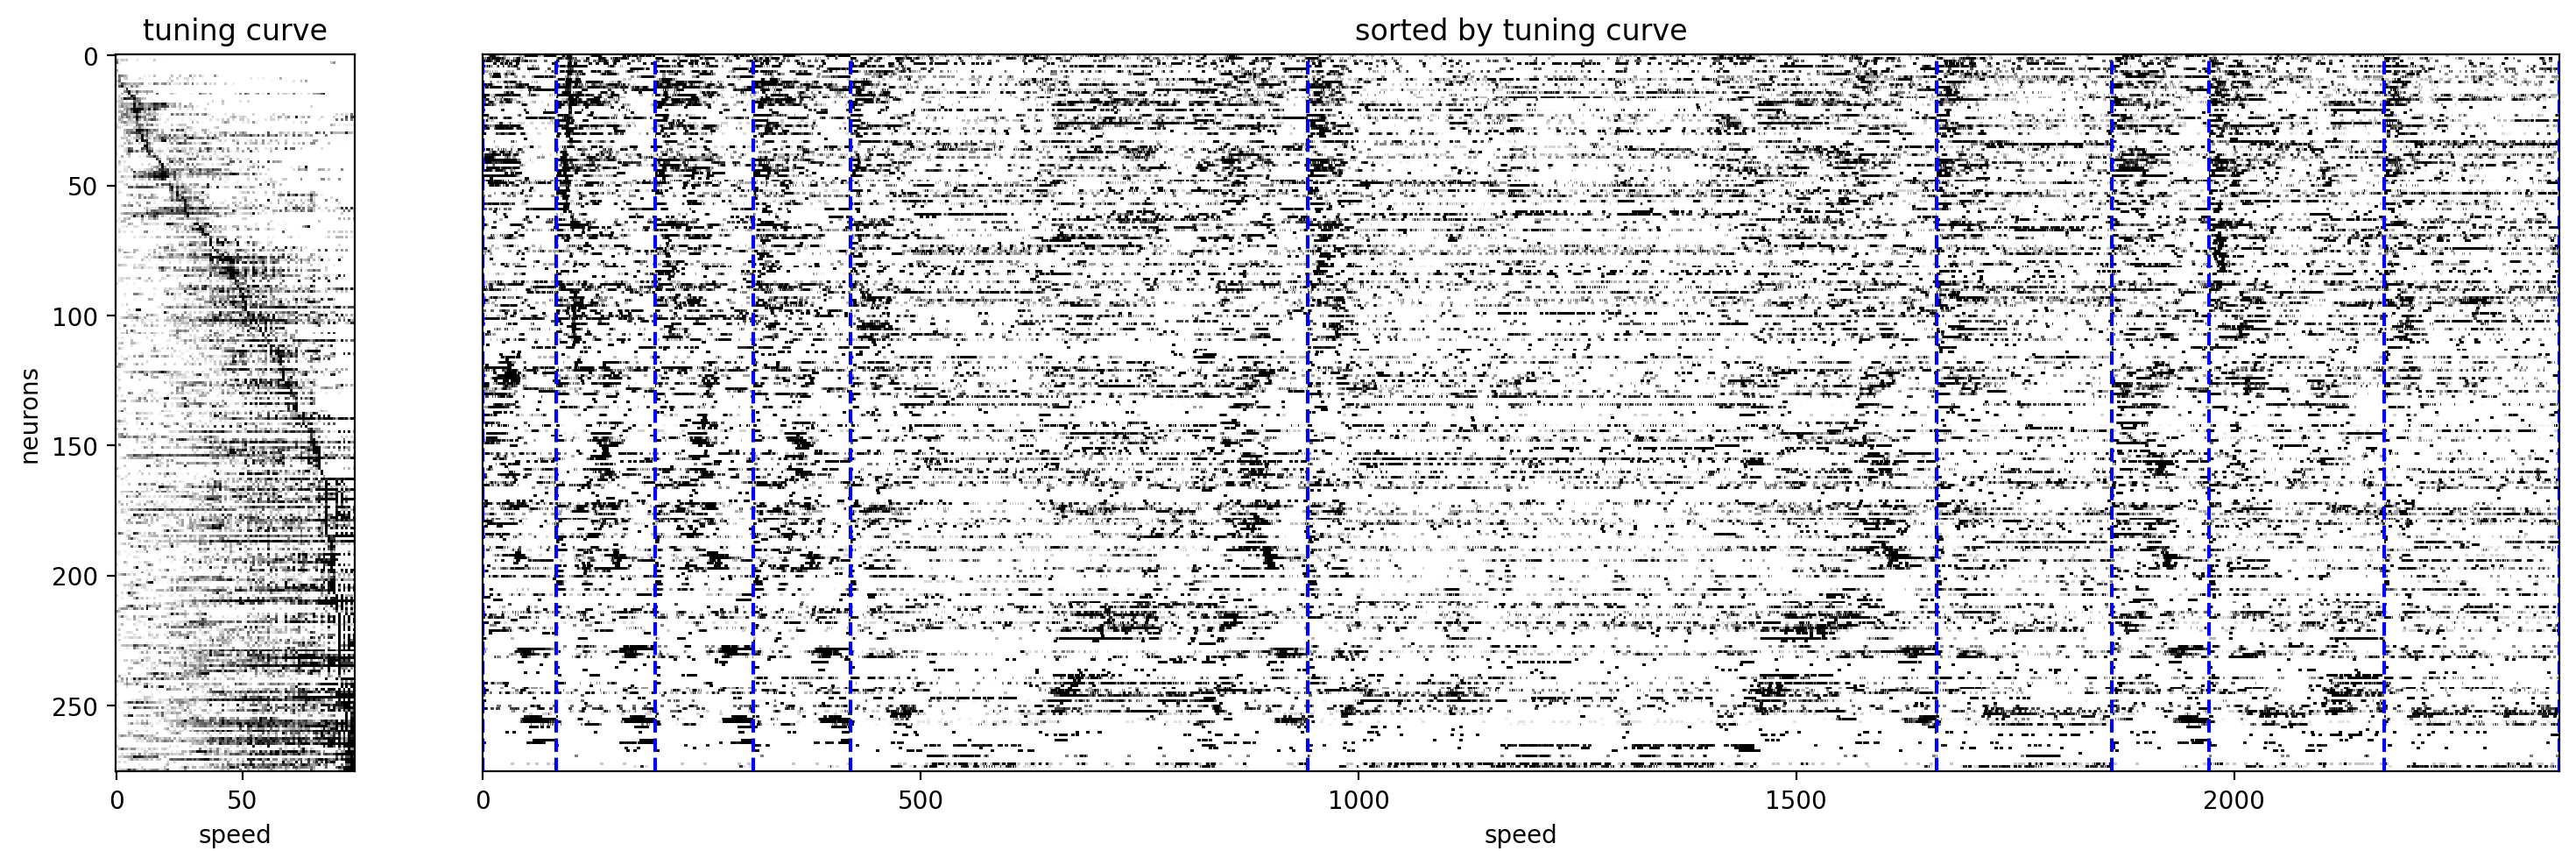

In [36]:
%autoreload
compression_var = ['y_pos', 'distance_shelter', 'escape','speed']
# for i, exp in enumerate(experiments_objects[7]):
exp = experiments_objects[7]
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip = load(exp)
for comp in compression_var:
    nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
    esc_var, escape_matrix, start = extract_escape_time(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp)
    tuning_matrix = creat_tuning_curve(esc_var, escape_matrix)
    plot_tuning_matrix(tuning_matrix, session, comp, escape_matrix, start)

In [33]:
def extract_escape_time(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, compression_var):
    """Tuning for each neuron is measured by compression_var"""
    # extract the time around escapes
    start = [0]
    for tr, of in enumerate(session.audio.onset_frames):
        if isinstance(of, list): of = of[0]
        if isinstance(of, np.ndarray): of = of[0]
        # find actual length of time until mouse is in shelter (or 5s if he never makes it)
        y_loc = y_pos[of:of + (20*40)]
        x_loc = x_pos[of:of + (20*40)]
        in_shelt_y = y_loc > session.shelter_location[0][1]
        in_shelt_x = np.logical_and(x_loc > session.shelter_location[0][0],x_loc < session.shelter_location[1][0])
        in_shelt = np.where(np.logical_and(in_shelt_x, in_shelt_y))[0]
        if len(in_shelt) == 0: in_shelt = 5*40 # cases when mouse never reaches shelter
        else: in_shelt = in_shelt[0]+40

        # extract variables
        neur = frame_by_cluster_matrix[of:of + in_shelt,:] # time x neurons
        this_speed = behave[of:of + in_shelt]
        this_y = y_pos[of:of + in_shelt]
        this_x = x_pos[of:of + in_shelt]

        # condition vector
        c = np.zeros((len(y_pos[of:of + in_shelt])))
        if bar[of] == True: c += 1
        if barflip[of] == True: c += 1

        bin_size = 10
        if compression_var == 'distance_shelter':
            var = compute_dist_shelt(this_x, this_y, c, session)
        elif compression_var == 'y_pos':
            var = this_y
        elif compression_var == 'escape':
            dd = compute_escape_trajectory(this_x, this_y)
            var = (dd/np.amax(dd))
            bin_size = .01
        elif compression_var == 'speed':
            var = this_speed
            bin_size = 1

        disc_var = discretize_x_axis(var, bin_size)

        # concatenate trials
        if tr == 0:
            escape_matrix = neur.T
            esc_var = disc_var
        else:
            escape_matrix = np.hstack((escape_matrix,neur.T))
            esc_var = np.append(esc_var, disc_var)
        
        start.append(len(esc_var))
    
    escape_matrix = zscore(escape_matrix, axis = 1)
    return esc_var, escape_matrix, start

In [32]:
def creat_tuning_curve(esc_var, escape_matrix):
    tuning_matrix = np.empty((np.shape(escape_matrix)[0],len(np.unique(esc_var))))
    for i, n in enumerate(escape_matrix):
        tuning_matrix[i,:] = firing_by_bin(esc_var, n, np.amax(esc_var)+1)
    return tuning_matrix

In [34]:
def plot_tuning_matrix(tuning_matrix, session, compression_var, escape_matrix, start):

    idx = np.argmax(tuning_matrix, axis = 1)
    isort = np.argsort(idx)

    fig = plt.figure(figsize=(18,6), dpi=200)
    grid = plt.GridSpec(9, 20, figure=fig, wspace = 0.05, hspace = 0.3)
    ax = plt.subplot(grid[:-1,:2])

    ax.imshow(tuning_matrix[isort,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
    ax.set_ylabel('neurons')
    ax.set_xlabel(compression_var)
    ax.set_title('tuning curve')

    ax = plt.subplot(grid[:-1, 3:])
    ax.imshow(escape_matrix[isort,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
    for i in start:
        ax.plot([i,i],[0,len(isort)],'--b')
    ax.set_xlabel(compression_var)
    ax.set_yticks([])
    ax.set_ylim([0,len(isort)])
    ax.set_xlim([0,start[-1]])
    ax.set_title('sorted by tuning curve')

    stim_resp_path = make_directory(os.path.join(session.base_path, session.processed_path, "stim_resp", "rastermap","tuning"))
    save_path=str(stim_resp_path) + "/" + nickname + ".png"
    fig.savefig(save_path)

    dump_path = "Z:/Jasmine_Laurence/escape_rastermap/tuning"
    fig.savefig(dump_path + "/" + nickname + ".png")
    # plt.close()